In [1]:
%matplotlib widget

from matplotlib import pyplot as plt
import glob
import numpy as np

from pymatgen.core import Structure, Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.transformations.standard_transformations import DeformStructureTransformation
import os

ImportError: cannot import name 'get_el_sp' from 'pymatgen.core' (C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\core\__init__.py)

In [ ]:
from __future__ import annotations

import os
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Sequence

import numpy as np
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator


# -----------------------------
# Simulation (physics) config
# -----------------------------
@dataclass
class SimConfig:
    wavelength: float = 0.181
    two_theta_range: Tuple[float, float] = (1.0, 15.0)
    n_points: int = 4096

    # instrument baseline
    inst_g_deg: float = 0.010
    inst_l_deg: float = 0.008

    # TOPAS-like broadening components
    components: List[tuple] = field(default_factory=lambda: [
        ("gauss", "const", 0.0136557396),
        ("lor",   "1/cos", 0.000630507138),
        ("gauss", "tan", 0.29767628),
    ])

    # augmentation
    background_max: float = 0.0002
    noise_max: float = 0.0002

# ------------------------------------------------------------
# Peak/profile helpers
# ------------------------------------------------------------
def gaussian_profile(x: np.ndarray, center: float, fwhm: float) -> np.ndarray:
    if fwhm <= 0:
        return np.zeros_like(x)
    sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    y = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    s = y.sum()
    return y / (s + 1e-12)


def lorentzian_profile(x: np.ndarray, center: float, fwhm: float) -> np.ndarray:
    if fwhm <= 0:
        return np.zeros_like(x)
    gamma = fwhm / 2.0
    y = gamma**2 / ((x - center) ** 2 + gamma**2)
    s = y.sum()
    return y / (s + 1e-12)


def pseudo_voigt_profile(x: np.ndarray, center: float, fwhm_g: float, fwhm_l: float) -> np.ndarray:
    """
    Simple pseudo-Voigt approximation.
    x, center, fwhm_* are in the same angular unit (degrees 2theta here).
    """
    if fwhm_g <= 0 and fwhm_l <= 0:
        return np.zeros_like(x)

    fg = max(fwhm_g, 1e-12)
    fl = max(fwhm_l, 1e-12)

    # Approximate Voigt FWHM and mixing parameter
    f = (fl**5 + 2.69269 * fl**4 * fg + 2.42843 * fl**3 * fg**2 +
         4.47163 * fl**2 * fg**3 + 0.07842 * fl * fg**4 + fg**5) ** (1.0 / 5.0)
    r = fl / (f + 1e-12)
    eta = 1.36603 * r - 0.47719 * r**2 + 0.11116 * r**3
    eta = float(np.clip(eta, 0.0, 1.0))

    g = gaussian_profile(x, center, f)
    l = lorentzian_profile(x, center, f)
    return (1.0 - eta) * g + eta * l

# ------------------------
# Angle-dependence helpers
# ------------------------
def dep_value(theta_rad, dep_type):
    """Return the basis function for dependence at theta (radians)."""
    if dep_type == "const":
        return 1.0
    elif dep_type == "tan":
        return np.tan(theta_rad)
    elif dep_type == "1/cos":
        return 1.0 / np.cos(theta_rad)
    else:
        raise ValueError(f"Unknown dependence type: {dep_type}")
    
def build_fwhm_from_instrument_params(theta_deg, components):
    """
    Build total FWHM from components.
    components: list of tuples (shape, dependence, a)
      shape: 'gauss' or 'lor'
      dependence: 'const', 'tan', '1/cos'
      a: numbers so component = a * dependence(theta)
    Returns: (fwhm_gauss_total, fwhm_lor_total)
    """
    theta_rad = np.deg2rad(theta_deg / 2.0)  # theta = Bragg angle = tth/2 (radians)
    # note: XRD two-theta is tth; convert to theta
    # accumulate gaussian contributions in quadrature and lorentzian linearly
    gauss_sum = 0.0
    lor_sum = 0.0
    for shape, dependence, a in components:
        base = a * dep_value(theta_rad, dependence)
        # ensure non-negative
        base = max(0.0, float(base))
        if shape.lower().startswith("g"):
            gauss_sum += base
        elif shape.lower().startswith("l"):
            lor_sum += base
        else:
            raise ValueError("shape must be 'gauss' or 'lor'")
    return gauss_sum*0.85, lor_sum

def size_strain_broadening(theta_rad: np.ndarray, wavelength: float, size_nm: float, microstrain: float, K: float = 0.9):
    """
    Returns broadening terms in radians of 2theta.
    """
    L_A = size_nm * 10.0  # nm -> Angstrom
    beta_size = (K * wavelength) / (L_A * np.cos(theta_rad) + 1e-12)   # Lorentzian-like
    beta_strain = 4.0 * microstrain * np.tan(theta_rad)                  # Gaussian-like
    return np.rad2deg(beta_size), np.rad2deg(beta_strain)


# ------------------------------------------------------------
# CIF -> full pattern
# ------------------------------------------------------------
def simulate_pattern_from_cif(
    cif_path: str,
    cfg: SimConfig,
    size_nm: float,
    microstrain: float,
    scale: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulate a single-phase full XRD pattern from CIF.
    """
    structure = Structure.from_file(cif_path)
    xrd = XRDCalculator(wavelength=cfg.wavelength, symprec=0.1)
    pat = xrd.get_pattern(structure, two_theta_range=cfg.two_theta_range)

    x = np.linspace(cfg.two_theta_range[0], cfg.two_theta_range[1], cfg.n_points)
    y = np.zeros_like(x, dtype=np.float64)

    # if no components specified, usefixed small instrument broadening, converted to radians then back to degrees later
    if cfg.components is None:
        beta_g_inst_fix = cfg.inst_g_deg
        beta_l_inst_fix = cfg.inst_l_deg

    else:
        components = cfg.components

    for tth, inten in zip(pat.x, pat.y):
        if inten <= 0:
            continue

        theta_rad = np.deg2rad(tth / 2.0)
        beta_size, beta_strain = size_strain_broadening(
            theta_rad=theta_rad,
            wavelength=cfg.wavelength,
            size_nm=size_nm,
            microstrain=microstrain,
        )
        # compute FWHM at this peak (two_theta units)
        beta_g_inst, beta_l_inst = (beta_g_inst_fix, beta_l_inst_fix) if (cfg.components is None) else build_fwhm_from_instrument_params(tth, components)
        # Combine widths in degrees of 2theta
        fwhm_g_deg = np.sqrt(beta_g_inst**2 + beta_strain**2)
        fwhm_l_deg = beta_l_inst + beta_size
        profile = pseudo_voigt_profile(x, tth, fwhm_g_deg, fwhm_l_deg)
        y += scale * inten * profile

    # Normalize to unit max so weights mean relative contribution
    y = y - y.min()
    if y.max() > 0:
        y = y / y.max()

    return x.astype(np.float32), y.astype(np.float32)


# ------------------------------------------------------------
# Mixture weight sampling
# ------------------------------------------------------------
def sample_mixture_weights(
    n_phases: int,
    dominant_range: Tuple[float, float] = (0.60, 0.90),
    minor_alpha: float = 0.35,
) -> np.ndarray:
    """
    Sample weights so that one phase is dominant and the rest are weak.
    Returns weights that sum to 1.
    """
    if n_phases <= 0:
        raise ValueError("n_phases must be >= 1")

    if n_phases == 1:
        return np.array([1.0], dtype=np.float32)

    dominant_idx = np.random.randint(n_phases)
    dominant_w = np.random.uniform(*dominant_range)
    remaining = 1.0 - dominant_w

    # Dirichlet for the minor phases
    minor = np.random.dirichlet(alpha=np.full(n_phases - 1, minor_alpha))
    minor = minor * remaining

    weights = np.zeros(n_phases, dtype=np.float32)
    weights[dominant_idx] = dominant_w
    weights[np.arange(n_phases) != dominant_idx] = minor
    weights = weights / weights.sum()
    return weights


# ------------------------------------------------------------
# Build one synthetic mixture
# ------------------------------------------------------------
def generate_mixture_pattern(
    cif_paths: Sequence[str],
    cfg: SimConfig,
    n_phases_range: Tuple[int, int] = (1, 4),
    allow_replacement: bool = False,
) -> Dict:
    """
    Generate one mixed XRD pattern from multiple CIFs.

    Returns a dict with:
      x, y, chosen_cifs, weights, size_nm, microstrain
    """
    cif_paths = list(cif_paths)
    if len(cif_paths) == 0:
        raise ValueError("cif_paths is empty")

    n_min, n_max = n_phases_range
    n_phases = random.randint(n_min, n_max)
    n_phases = min(n_phases, len(cif_paths)) if not allow_replacement else n_phases

    chosen = random.sample(cif_paths, n_phases) if not allow_replacement else random.choices(cif_paths, k=n_phases)
    weights = sample_mixture_weights(n_phases)

    x = np.linspace(cfg.two_theta_range[0], cfg.two_theta_range[1], cfg.n_points)
    y_mix = np.zeros_like(x, dtype=np.float64)

    phase_meta = []

    for cif_path, w in zip(chosen, weights):
        # Per-phase variability
        size_nm = np.random.uniform(20.0, 200.0)
        microstrain = np.random.uniform(0.0, 0.002)

        x_i, y_i = simulate_pattern_from_cif(
            cif_path=cif_path,
            cfg=cfg,
            size_nm=size_nm,
            microstrain=microstrain,
            scale=1.0,
        )

        # x_i should match x if cfg is fixed; kept here for clarity
        y_mix += float(w) * y_i

        phase_meta.append({
            "cif": os.path.basename(cif_path),
            "weight": float(w),
            "size_nm": float(size_nm),
            "microstrain": float(microstrain),
        })

    # Add background
    bg_level = np.random.uniform(0.0, cfg.background_max)
    bg = bg_level * (1.0 + 0.02 * (x - x.mean()) + 0.0005 * (x - x.mean()) ** 2)
    y_mix += bg

    # Add noise
    noise_level = np.random.uniform(0.0, cfg.noise_max)
    y_mix += np.random.normal(0.0, noise_level * max(y_mix.max(), 1e-12), size=y_mix.shape)

    # Normalize
    y_mix = y_mix - y_mix.min()
    if y_mix.max() > 0:
        y_mix = y_mix / y_mix.max()

    return {
        "x": x.astype(np.float32),
        "y": y_mix.astype(np.float32),
        "chosen_cifs": chosen,
        "weights": weights.astype(np.float32),
        "phases": phase_meta,
    }


# ------------------------------------------------------------
# Batch generator
# ------------------------------------------------------------
def generate_mixture_batch(
    cif_paths: Sequence[str],
    cfg: SimConfig,
    n_samples: int = 100,
    n_phases_range: Tuple[int, int] = (2, 4),
) -> List[Dict]:
    """
    Generate a batch of synthetic mixture patterns.
    """
    batch = []
    for _ in range(n_samples):
        sample = generate_mixture_pattern(
            cif_paths=cif_paths,
            cfg=cfg,
            n_phases_range=n_phases_range,
            allow_replacement=False,
        )
        batch.append(sample)
    return batch

In [ ]:
basepath = "C:/Users/hzhong/OneDrive - Brookhaven National Laboratory/Project/2026/XRD_QC/"
cifpath = basepath + "cifs/"
datapath = basepath + "data/"

In [ ]:
# Obtain a CIF file for CeO2 from the current directory.
ciffile = glob.glob("*LaB6*.cif")[0]
os.path.splitext(os.path.basename(ciffile))[0]
print(os.path.basename(ciffile))

LaB6_Entry_04-002-0015.cif


In [ ]:
# Change the lattice of the structure in two ways:
structure = Structure.from_file(ciffile)
# Scale the lattice (`lattice_scale` is the new volume of the lattice, equal to `a * b * c`), or
lattice_scale = 1250
# structure.scale_lattice(lattice_scale)
# Create an all-new lattice from set parameters and transform the structure while still maintaining relative atom position.
angles = structure.lattice.angles
new_lattice = Lattice.from_parameters(a = 10, b = 10, c = 10, alpha = angles[0], beta = angles[1], gamma = angles[2])
# NEW_LAT = TRANS * OG_LAT, so TRANS = NEW_LAT * (OG_LAT)^-1.
transformation = np.dot(new_lattice.matrix, np.linalg.inv(structure.lattice.matrix))
# Create a new transformation and apply it to the structure.
transformation = DeformStructureTransformation(transformation)
# structure = transformation.apply_transformation(structure)

C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\io\cif.py:286: UserWarning: Possible issue in CIF file at line: Lanthanum
  block = CifBlock.from_str(f"data_{block_str}")
C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\io\cif.py:286: UserWarning: Possible issue in CIF file at line: Inorg. Mater. (Engl. Transl.).
  block = CifBlock.from_str(f"data_{block_str}")
C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\io\cif.py:1068: UserWarning: b parsed as B
  symbol = self._parse_symbol(label)
C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\io\cif.py:1068: UserWarning: la parsed as La
  symbol = self._parse_symbol(label)
C:\Users\jaked\AppData\Roaming\Python\Python312\site-packages\pymatgen\core\structure.py:3172: UserWarning: Issues encountered while parsing CIF: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _symmetry_space_group_name_H-M used.
b parsed as B
la parsed as La
  struct = p

4.157 4.157 4.157


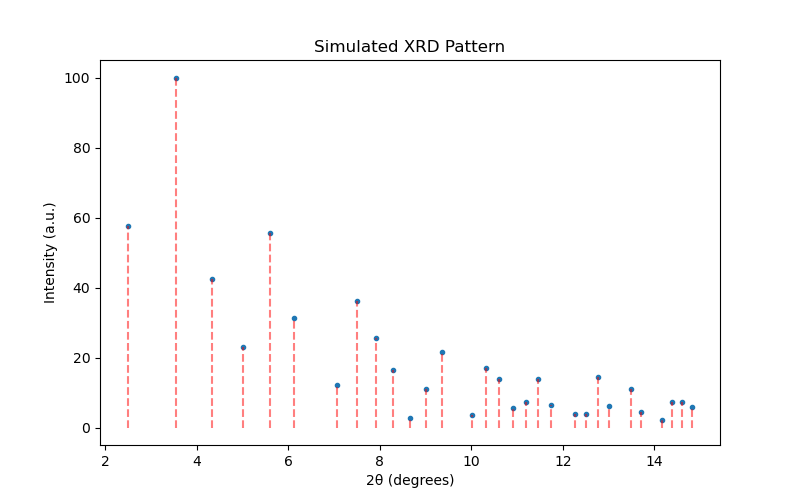

In [ ]:
print(structure.lattice.a, structure.lattice.b, structure.lattice.c)
xrd = XRDCalculator(wavelength=0.1812, symprec=0.1)
pat = xrd.get_pattern(structure, two_theta_range=(1, 15))
plt.figure(figsize=(8, 5))
plt.plot(pat.x, pat.y,'.')
plt.vlines(pat.x, 0, pat.y, colors='r', linestyles='dashed', alpha=0.5)
plt.xlabel("2θ (degrees)")  
plt.ylabel("Intensity (a.u.)")
plt.title("Simulated XRD Pattern")  
plt.show()

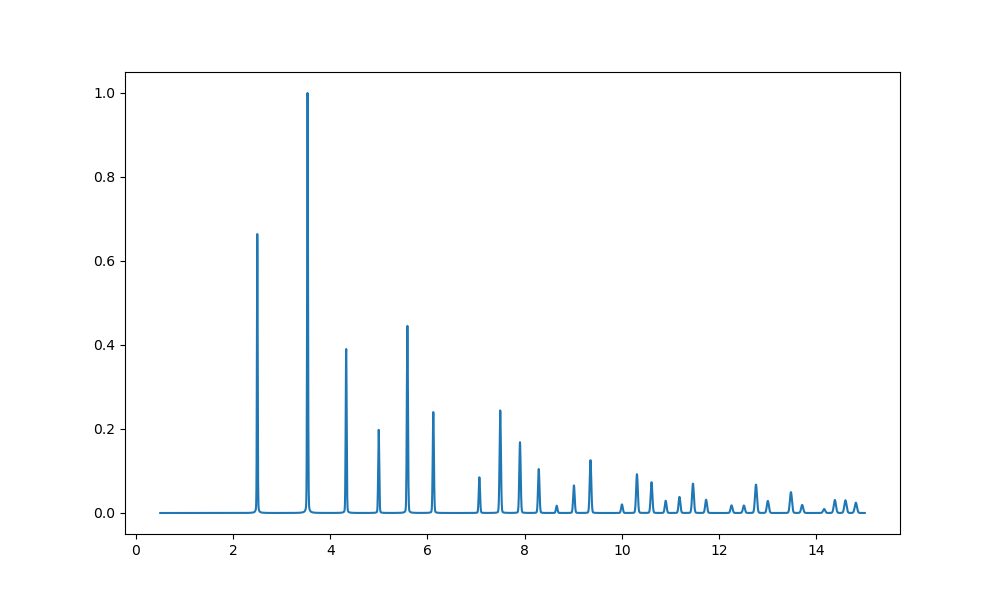

In [ ]:
cfg = SimConfig(
    wavelength=0.1812,
    two_theta_range=(0.5, 15.0),
    n_points=4096,
)
size_nm = 380
microstrain = 0.001
pattern = simulate_pattern_from_cif(ciffile, cfg, size_nm=size_nm, microstrain=microstrain)
plt.figure(figsize=(10, 6))
plt.plot(pattern[0], pattern[1])    
plt.show()

LaB6_XRD_0_20260318-110213_694d86_primary-dk_sub_image-00000.xy


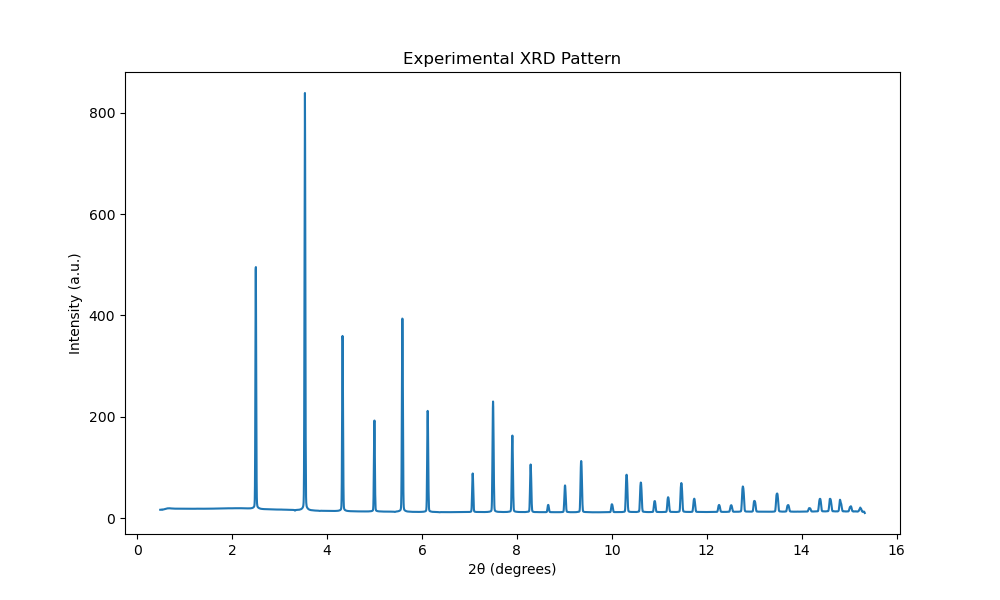

In [ ]:
CeO2_dat = glob.glob("*LaB6*.xy")[0]
print(os.path.basename(CeO2_dat))
x, y = np.loadtxt(CeO2_dat, unpack=True)
plt.figure(figsize=(10, 6)) 
plt.plot(x, y)
plt.xlabel("2θ (degrees)")  
plt.ylabel("Intensity (a.u.)")
plt.title("Experimental XRD Pattern")  

plt.show()



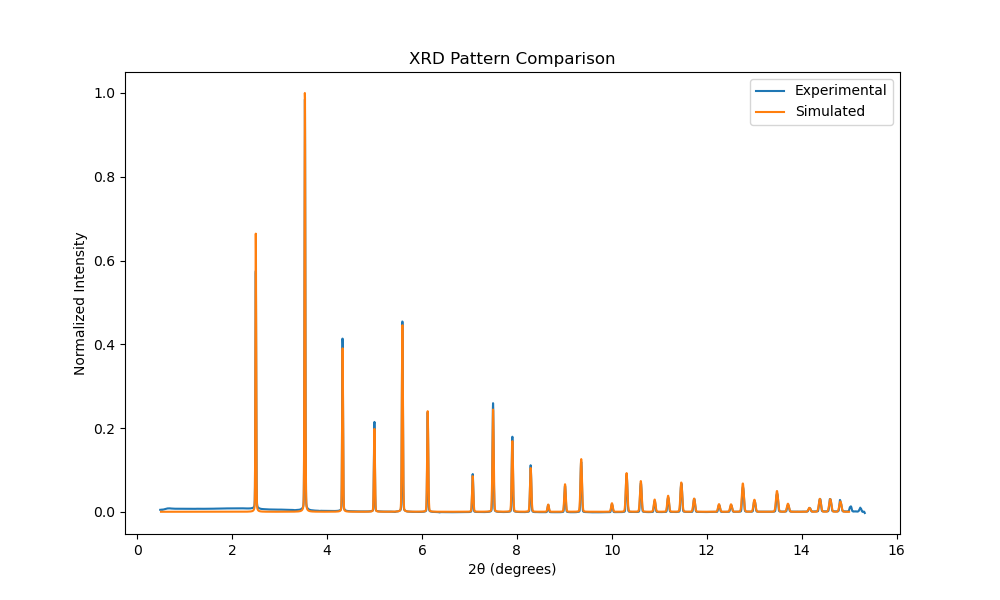

In [ ]:
offset = 0.015
plt.figure(figsize=(10, 6))
plt.plot(x, y/np.max(y)-offset, label='Experimental')
plt.plot(pattern[0], pattern[1]/np.max(pattern[1]), label='Simulated')
plt.xlabel("2θ (degrees)")  
plt.ylabel("Normalized Intensity")
plt.title("XRD Pattern Comparison")  
plt.legend()
plt.show()